In [1]:
import os
import gc
from pathlib import Path

import numpy as np
from sklearn.preprocessing import StandardScaler

import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
from matplotlib_venn import venn2, venn3

from upsetplot import generate_counts, UpSet, plot, from_indicators

import seaborn as sns

import anndata as ad
import scanpy as sc

%matplotlib inline

In [2]:
## Import AnnData Object ##

adata = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata_annotated_w_celltypist_scanvi.h5ad')

## Toss Stressed Glia & Doublets ##

adata = adata[~(adata.obs['subclass_annotations'] == 'Stressed Glia') & ~adata.obs['pred_dbl']].copy()
gc.collect()

# Create Pseudobulk Col ##

adata.obs['Donor_Sample'] = adata.obs['Donor'].astype('str') + '_' + adata.obs['Sample Name'].astype('str')

In [3]:
## Known Genes In Deleted Regions ##

# https://bioinfo.uth.edu/SZGR/display/showGeneset #

GENES_22q11_2_ARM = ["DERL3", "LRP5L", "SGSM1", "C22orf15", "LOC284890", "C22orf36", "PIWIL3", "GSTT2B",
                    "DDTL", "SMARCB1", "VPREB3", "SERPIND1", "MAPK1", "HIRA", "ZNF74", "CLTCL1",
                    "VPREB1", "GSTT2", "MMP11", "ZNF70", "CRYBB1", "CRKL", "BCR", "ADRBK2",
                    "MN1", "CHEK2", "APOL2", "C22orf28", "LOC652968", "FBXO7", "PVALB", "PPARA",
                    "TPST2", "PES1", "SEZ6L", "PITPNB", "TFIP11", "C22orf31", "ASPHD2", "KREMEN1",
                    "ZNRF3", "ASCC2", "HSCB", "CCDC117", "RHBDD3", "C22orf24", "TIMP3", "TBC1D10A",
                    "XBP1", "EWSR1", "LIF", "LIMK2", "DRG1", "NEFH", "NF2", "OSM",
                    "RFPL1", "SMTN", "TCN2", "NIPSNAP1", "THOC5", "MTMR3", "GAL3ST1", "SFI1",
                    "SF3A1", "RASL10A", "GAS2L1", "MORC2", "SEC14L2", "PATZ1", "PISD", "OSBP2",
                    "RNF185", "PIK3IP1", "EMID1", "SELM", "HORMAD2", "DUSP18", "CABP7", "RNF215",
                    "SEC14L3", "SEC14L4", "SLC35E4", "LOC550631", "SLC5A4", "C22orf30", "DGCR5",
                    "DGCR6L", "SUSD2", "SCZD4", "BID", "IL17RA", "BCL2L13", "TUBA8", "GAB4",
                    "CCT8L2", "XKR3", "TRMT2A", "RTDR1", "CECR2", "YPEL1", "LOC51233", "MED15",
                    "UPB1", "CECR1", "DGCR8", "GNB1L", "EIF4ENIF1", "SLC2A11", "THAP7", "OR11H1",
                    "C22orf13", "SLC25A18", "MYO18B", "CRYBB2", "CRYBB3", "CRYBA4", "PLA2G3",
                    "APOL4", "ACO2", "ARVCF", "GSC2", "PI4KA", "SEPT5", "PRODH", "RANBP1",
                    "SLC7A4", "SLC25A1", "TBX1", "CLDN5", "UBE2L3", "UFD1L", "CDC45L", "SNAP29",
                    "DGCR2", "TXNRD2", "USP18", "HIC2", "TSSK2", "SDF2L1", "PPIL2", "ZDHHC8",
                    "PEX26", "MICAL3", "MRPL40", "RTN4R", "C22orf29", "KLHL22", "SCARF2",
                    "C22orf25", "AIFM3", "CCDC116", "FLJ42953", "LOC440792", "COMT", "GP1BB",
                    "DGCR6", "LZTR1", "DGCR14", "GNAZ", "TOP3B", "RAB36", "PPM1F", "PRAME",
                    "DKFZP434P211", "LOC96610", "ZNF280A", "ZNF280B", "ADORA2A", "DDT",
                    "GGT1", "GSTT1", "IGLL1", "MIF", "SNRPD3", "SPECC1L", "CABIN1"]

CLASSIC_22q11 = ['TBX1', "COMT", "DGCR8", "TANGO2"]

CLASSIC_3q29 = ['DLG1', "PAK2", "TFRC", "C3orf34"]
BORDERLINE_3q29 = ['HES1', "CLDN1", "OPA1"]
ALL_3q29 = adata.var_names[adata.var_names.isin(CLASSIC_3q29 + BORDERLINE_3q29)].tolist()

CLASSIC_15q13 = ['HERC2', 'CHRFAM7A', 'CHP', 'FMN1']
BORDERLINE_15q13 = ['SCG5', 'SLC12A6', 'GREM1', 'MAP1A']
ALL_15q13 = adata.var_names[adata.var_names.isin(CLASSIC_15q13 + BORDERLINE_15q13)].tolist()

In [4]:
## Read in DEG Lists ##

CSV_PATH = '/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/disease_analyses/'

dge_22q11 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_22q11_dge_scz_results.csv')
dge_22q11 = dge_22q11.merge(adata.var[['chromosome_name']], right_index=True, left_on='ID', how='left')

dge_NRXN1 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_NRNXN1_dge_scz_results.csv')
dge_NRXN1 = dge_NRXN1.merge(adata.var[['chromosome_name']], right_index=True, left_on='ID', how='left')

dge_3q29 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_3q29_dge_scz_results.csv')
dge_3q29 = dge_3q29.merge(adata.var[['chromosome_name']], right_index=True, left_on='ID', how='left')

dge_15q13 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_15q13_dge_scz_results.csv')
dge_15q13 = dge_15q13.merge(adata.var[['chromosome_name']], right_index=True, left_on='ID', how='left')

dge_Idiopathic = pd.read_csv(Path(CSV_PATH) / 'dreamlet_Idiopathic_dge_scz_results.csv')
dge_Idiopathic = dge_Idiopathic.merge(adata.var[['chromosome_name']], right_index=True, left_on='ID', how='left')

In [5]:
## 22q11 Deletion DGE Manipulate ##

# Get index of max t per gene
idx = dge_22q11.groupby('ID')['t'].idxmax()

# Build mapping: gene → best assay
best_assay_map = dge_22q11.loc[idx].set_index('ID')['assay']

# Map back to all rows
dge_22q11['assay_max'] = dge_22q11['ID'].map(best_assay_map)

In [6]:
## Idiopathic Deletion DGE Manipulate ##

# Get index of max t per gene
idx_idio = dge_Idiopathic.groupby('ID')['t'].idxmax()

# Build mapping: gene → best assay
best_assay_map_idio = dge_Idiopathic.loc[idx_idio].set_index('ID')['assay']

# Map back to all rows
dge_Idiopathic['assay_max'] = dge_Idiopathic['ID'].map(best_assay_map_idio)

In [7]:
## Unique DGES ##

UNIQUE_22q11 = np.unique(dge_22q11[(dge_22q11['adj.P.Val'] < 0.05)]['ID'])

UNIQUE_NRXN1 = np.unique(dge_NRXN1[(dge_NRXN1['adj.P.Val'] < 0.05)]['ID'])

UNIQUE_3q29 = np.unique(dge_3q29[(dge_3q29['adj.P.Val'] < 0.05)]['ID'])

UNIQUE_15q13 = np.unique(dge_15q13[(dge_15q13['adj.P.Val'] < 0.05)]['ID'])

UNIQUE_Idiopathic = np.unique(dge_Idiopathic[(dge_Idiopathic['adj.P.Val'] < 0.05)]['ID'])

ALL_UNIQUES = UNIQUE_22q11.tolist() + UNIQUE_NRXN1.tolist() + UNIQUE_3q29.tolist() + UNIQUE_15q13.tolist() + UNIQUE_Idiopathic.tolist()  

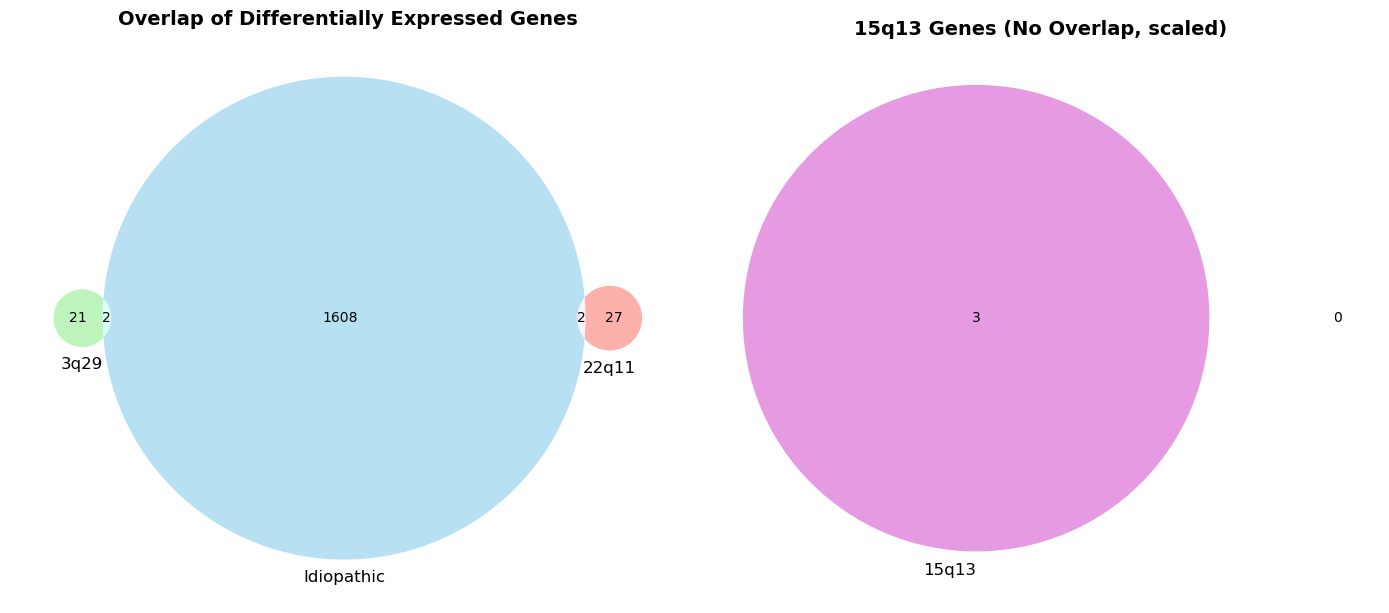

In [8]:
## Venn Diagrams ##

# Unique Genes as Sets #
set_idiopathic = set(UNIQUE_Idiopathic)
set_3q29 = set(UNIQUE_3q29)
set_22q11 = set(UNIQUE_22q11)
set_15q13 = set(UNIQUE_15q13)

# Sizes for scaling 15q13 relative to other sets
max_size = max(len(set_idiopathic), len(set_3q29), len(set_22q11))
subset_15q13 = (len(set_15q13), 0, 0)  # only the first circle counts, no overlap

# Plot #
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# --- 3-set Venn diagram ---
plt.sca(axes[0])
venn3([set_idiopathic, set_3q29, set_22q11],
      set_labels=('Idiopathic', '3q29', '22q11'),
      set_colors=('skyblue', 'lightgreen', 'salmon'),
      alpha=0.6)
plt.title('Overlap of Differentially Expressed Genes', fontsize=14, fontweight='bold')

# --- 15q13 standalone circle ---
plt.sca(axes[1])
venn2(subsets=subset_15q13,
      set_labels=('15q13', ''),
      set_colors=('orchid', 'white'),
      alpha=0.7)
plt.title('15q13 Genes (No Overlap, scaled)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [9]:
## Overlapping DGEs Dot Plot ##

dfs = [dge_22q11, dge_NRXN1, dge_3q29, dge_15q13, dge_Idiopathic]

all_dges = pd.concat([df.assign(key=k) for df, k in zip(dfs, ["22q11", "NRXN1", "3q29", "15q13", "Idiopathic"])],
                     axis=0, ignore_index=True)

intersection_genes = list(set_idiopathic.intersection(set_3q29)) + list(set_idiopathic.intersection(set_22q11))

all_dges_overlap = all_dges[all_dges['ID'].isin(intersection_genes) & (all_dges['adj.P.Val'] < 0.05)]

all_dges_overlap["x"] = all_dges_overlap["key"].astype(str) + " | " + all_dges["assay"]

all_dges_overlap['neglogP'] = -np.log(all_dges_overlap['adj.P.Val'])



/tmp/ipykernel_54616/1557605362.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_dges_overlap["x"] = all_dges_overlap["key"].astype(str) + " | " + all_dges["assay"]
/tmp/ipykernel_54616/1557605362.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_dges_overlap['neglogP'] = -np.log(all_dges_overlap['adj.P.Val'])


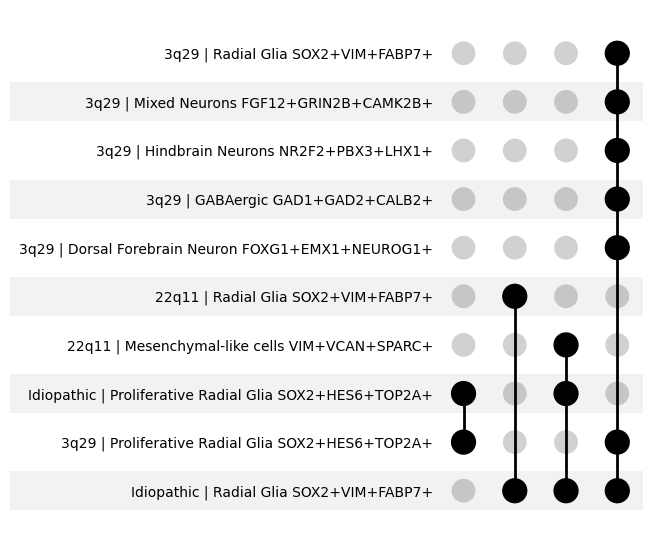

In [10]:
# Step 1: Create a dictionary of sets of genes per x
gene_sets = all_dges_overlap.groupby('x')['ID'].apply(set)

# Step 2: Find all genes that appear in more than one x
gene_counts = pd.Series([gene for genes in gene_sets for gene in genes])
shared_genes = gene_counts[gene_counts.duplicated(keep=False)].unique()

# Step 3: Build a boolean matrix: rows = shared genes, columns = x labels
rows = []
for gene in shared_genes:
    row = {x_label: gene in genes for x_label, genes in gene_sets.items()}
    row['gene'] = gene
    rows.append(row)

shared_df = pd.DataFrame(rows).set_index('gene')

# Step 4: Convert to UpSet format
upset_data = from_indicators(shared_df)

# Step 5: Plot
fig = plt.figure(figsize=(20, 6))

# Pass the figure to the plot method
upset = UpSet(upset_data, show_counts=True, with_lines=True, element_size=49, intersection_plot_elements=(), totals_plot_elements=0)
upset.plot(fig=fig)

plt.xticks(rotation=45, ha='right')  # rotate labels to prevent overlap
#plt.tight_layout()  # adjust layout so nothing is cut off
plt.show()

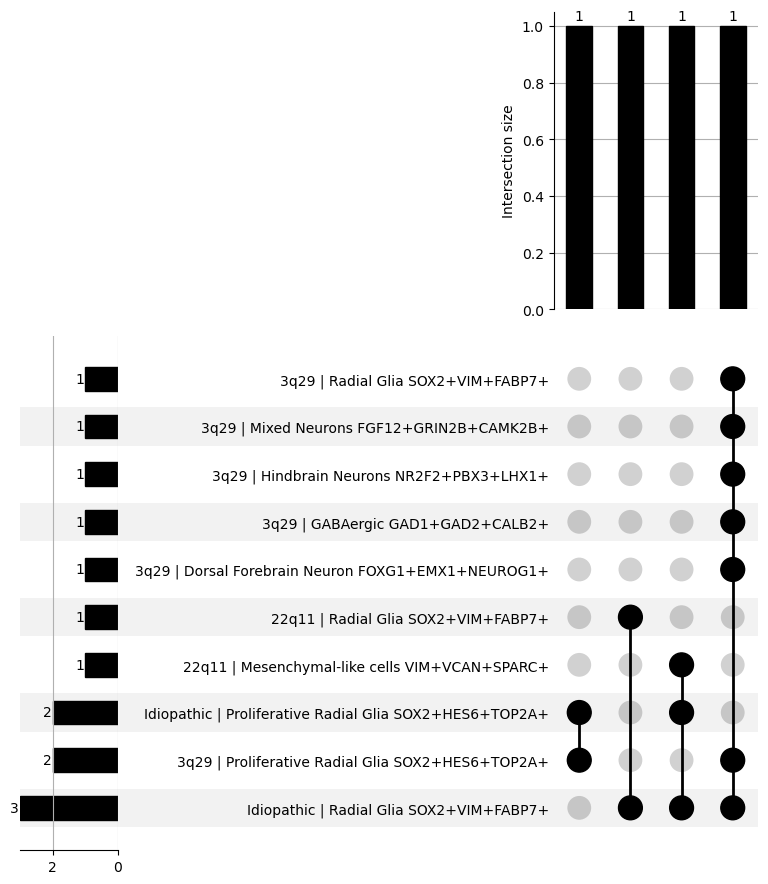

In [11]:
# Step 4: Convert to UpSet format
upset_data = from_indicators(shared_df)

# Step 5: Plot
fig = plt.figure(figsize=(20, 6))

# Pass the figure to the plot method
upset = UpSet(upset_data, show_counts=True, with_lines=True, element_size=49)
upset.plot(fig=fig)

plt.xticks(rotation=45, ha='right')  # rotate labels to prevent overlap
#plt.tight_layout()  # adjust layout so nothing is cut off
plt.show()

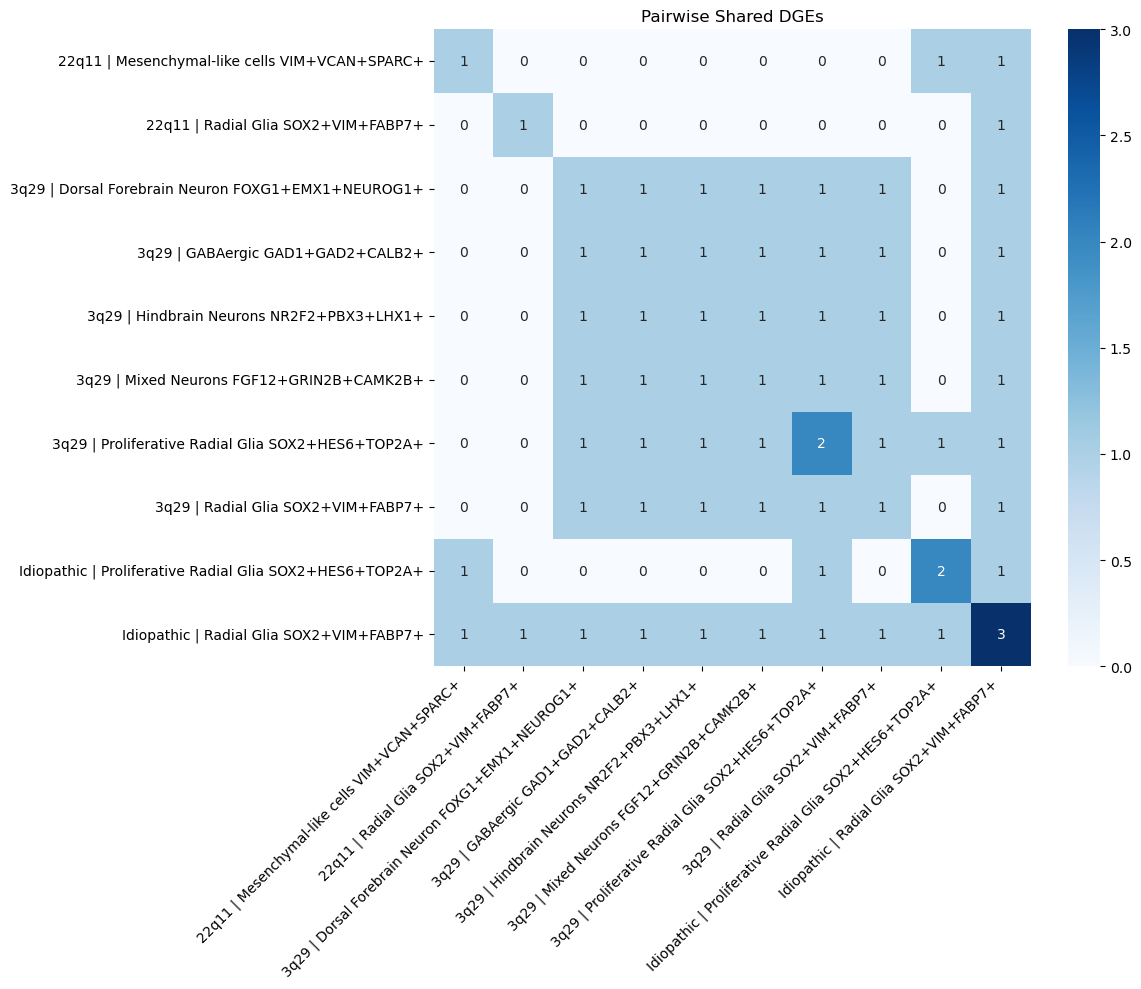

In [12]:
## Heatmap Representation of Shaerd Overlap ##

# Create pairwise overlap counts
x_labels = list(gene_sets.keys())
overlap_matrix = pd.DataFrame(0, index=x_labels, columns=x_labels)

for i, set1 in enumerate(x_labels):
    for j, set2 in enumerate(x_labels):
        overlap_matrix.loc[set1, set2] = len(gene_sets[set1] & gene_sets[set2])

# Plot as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(overlap_matrix, annot=True, fmt="d", cmap="Blues")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Pairwise Shared DGEs")
plt.tight_layout()
plt.show()

/tmp/ipykernel_54616/2899120258.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


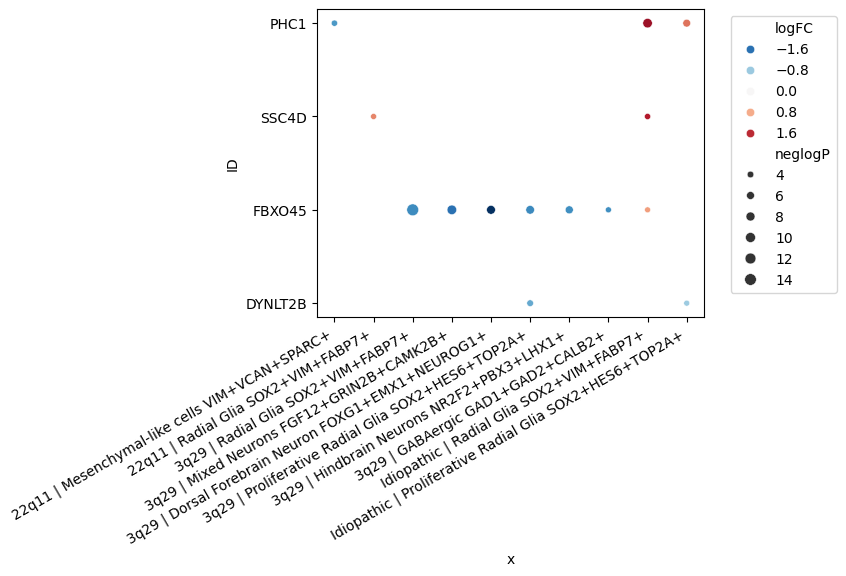

In [13]:
# Set a diverging colormap, e.g., red-white-blue
cmap = plt.get_cmap("RdBu_r")  # _r reverses it so red = positive, blue = negative

# Scatterplot
ax = sns.scatterplot(
    data=all_dges_overlap,
    x="x",
    y="ID",
    hue="logFC",
    size="neglogP",
    palette=cmap,
    hue_norm=(-all_dges_overlap["logFC"].abs().max(), all_dges_overlap["logFC"].abs().max())  # centers around 0
)

# Figure adjustments
ax.figure.set_size_inches(5, 4)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

In [34]:
# Make DataFrame for 22q11 only #

# take the manuscripts that all study 22q11
shin_khan_rao_logical = adata.obs['Manuscript'].str.contains('Shin|Khan|Rao')
# extract walsh 22q11 lines and walsh controls, but not 15q13 lines
walsh_22q11_logical = (adata.obs['Manuscript'] == 'Walsh') & (adata.obs['Broad_Genotype'] != '15q13.3del') 

# make anndata of 22q11
adata_22q11 = adata[shin_khan_rao_logical | walsh_22q11_logical]
adata_22q11.obs['Donor_Sample_Subclass'] = (adata_22q11.obs['Donor_Sample'].astype('str') + '_' + 
                                            adata_22q11.obs['subclass_annotations_markers'].astype('str'))

# sort genes for 22q11 by celltype
SORTED_22q11s = dge_22q11[(dge_22q11['adj.P.Val'] < 0.05)].sort_values(by=['assay', 'logFC'], ascending=False)['ID'].tolist()


adata_df_22q11 = pd.DataFrame(data=adata_22q11[:,SORTED_22q11s].layers['raw_counts'].toarray(),
                     index=adata_22q11.obs_names,
                     columns=adata_22q11[:,SORTED_22q11s].var_names)

# Add Donor Column #
# adata_df_22q11['Donor_Sample'] = adata_22q11[:,SORTED_22q11s].obs['Donor_Sample']
adata_df_22q11['Donor_Sample_Subclass'] = (adata_22q11[:,SORTED_22q11s].obs['Donor_Sample'].astype('str') + '_' + 
                                           adata_22q11[:,SORTED_22q11s].obs['subclass_annotations_markers'].astype('str'))

# # Pseudobulk #
pseudobulk_df = adata_df_22q11.groupby('Donor_Sample_Subclass').mean()
pseudobulk_df = np.log1p(pseudobulk_df)

# Create Broad_Genotype with Donor-Broad Genotype dictionary and sort by it #
donor_genotype_dict = dict(zip(adata_22q11.obs['Donor_Sample_Subclass'], adata_22q11.obs['Broad_Genotype']))
donor_manuscript_dict = dict(zip(adata_22q11.obs['Donor_Sample_Subclass'], adata_22q11.obs['Manuscript']))
donor_subclass_dict = dict(zip(adata_22q11.obs['Donor_Sample_Subclass'], adata_22q11.obs['subclass_annotations_markers']))

pseudobulk_df['Broad_Genotype'] = pd.Series(pseudobulk_df.index).apply(lambda x: donor_genotype_dict[x]).values
pseudobulk_df['Manuscript'] = pd.Series(pseudobulk_df.index).apply(lambda x: donor_manuscript_dict[x]).values
pseudobulk_df['Subclass'] = pd.Series(pseudobulk_df.index).apply(lambda x: donor_subclass_dict[x]).values

pseudobulk_df = pseudobulk_df.sort_values(by=['Broad_Genotype', 'Subclass', 'Manuscript'])

/tmp/ipykernel_54616/1993262033.py:10: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_22q11.obs['Donor_Sample_Subclass'] = (adata_22q11.obs['Donor_Sample'].astype('str') + '_' +


In [35]:
## Build Row Color DF ##

manuscript_subclass_df = pd.DataFrame({'Manuscript': pd.Series(pseudobulk_df.index).map(donor_manuscript_dict).values,
                                       'Broad_Genotype': pd.Series(pseudobulk_df.index).map(donor_genotype_dict).values,
                                       'Subclass': pd.Series(pseudobulk_df.index).map(donor_subclass_dict).values},
                                      index=pseudobulk_df.index)

## Broad_Genotype Colors ##
broad_genotypes = manuscript_subclass_df['Broad_Genotype'].unique()
bd_palette = sns.color_palette("Set1", len(broad_genotypes))
bd_color_map = dict(zip(broad_genotypes, bd_palette))

# Manuscript Colors #
manuscripts = manuscript_subclass_df['Manuscript'].unique()
manuscript_palette = sns.color_palette("Set2", len(manuscripts))
manuscript_color_map = dict(zip(manuscripts, manuscript_palette))

# Celltype Colors #
subclasses = manuscript_subclass_df['Subclass'].unique()
subclass_palette = sns.color_palette("tab20", len(subclasses))
subclass_color_map = dict(zip(subclasses, subclass_palette))

# Add New Colors #
manuscript_subclass_df['manuscript_color'] = manuscript_subclass_df['Manuscript'].map(manuscript_color_map) #.apply(to_hex)
manuscript_subclass_df['subclass_color'] = manuscript_subclass_df['Subclass'].map(subclass_color_map) #.apply(to_hex)
manuscript_subclass_df['bd_color'] = manuscript_subclass_df['Broad_Genotype'].map(bd_color_map)

# Reset Index to Broad Genotype #
del pseudobulk_df['Broad_Genotype']
del pseudobulk_df['Manuscript']
del pseudobulk_df['Subclass']

In [36]:
## Build Col Color DF ##

gene_subclass_dict = dict(zip(dge_22q11['ID'], dge_22q11['assay_max']))

celltype_gene_df = pd.DataFrame({'Cell Type': pd.Series(pseudobulk_df.columns).map(gene_subclass_dict).values, 
                                '22q11_Arm':pd.Series(pseudobulk_df.columns).apply(lambda x: True if x in GENES_22q11_2_ARM else False).values},
                                index=pseudobulk_df.columns)

## gene-subtypes to colors ##
celltypes = celltype_gene_df['Cell Type'].unique()
celltype_palette = sns.color_palette("tab20", len(celltypes))
celltype_color_map = dict(zip(celltypes, celltype_palette))
celltype_gene_df['Cell_Type_Color'] = celltype_gene_df['Cell Type'].map(celltype_color_map)

## gene-subtypes to colors ##
arm_status = celltype_gene_df['22q11_Arm'].unique()
arm_palette = sns.color_palette("Set1", len(arm_status))
celltype_22q11_status_map = dict(zip(arm_status, arm_palette))
celltype_gene_df['22q11_Arm_Colors'] = celltype_gene_df['22q11_Arm'].map(celltype_22q11_status_map)

# organize genes into subclass
celltype_gene_df = celltype_gene_df.sort_values(by=['22q11_Arm', 'Cell Type'], ascending=False)
celltype_gene_df = celltype_gene_df[~celltype_gene_df.index.duplicated(keep='first')]

# take non duplicate columns
pseudobulk_df = pseudobulk_df[pseudobulk_df.columns.unique()]
pseudobulk_df = pseudobulk_df.loc[:, ~pseudobulk_df.columns.duplicated()]
pseudobulk_df = pseudobulk_df[celltype_gene_df.index]

In [37]:
## Scaling ##

pseudobulk_scaled = pseudobulk_df.copy()

# Z-score per gene (keeps structure but reveals contrast)
pseudobulk_scaled = (
    pseudobulk_scaled - pseudobulk_scaled.mean(axis=0)
) / pseudobulk_scaled.std(axis=0)

# Clip for visualization
pseudobulk_scaled = pseudobulk_scaled.clip(-2, 2)

[]

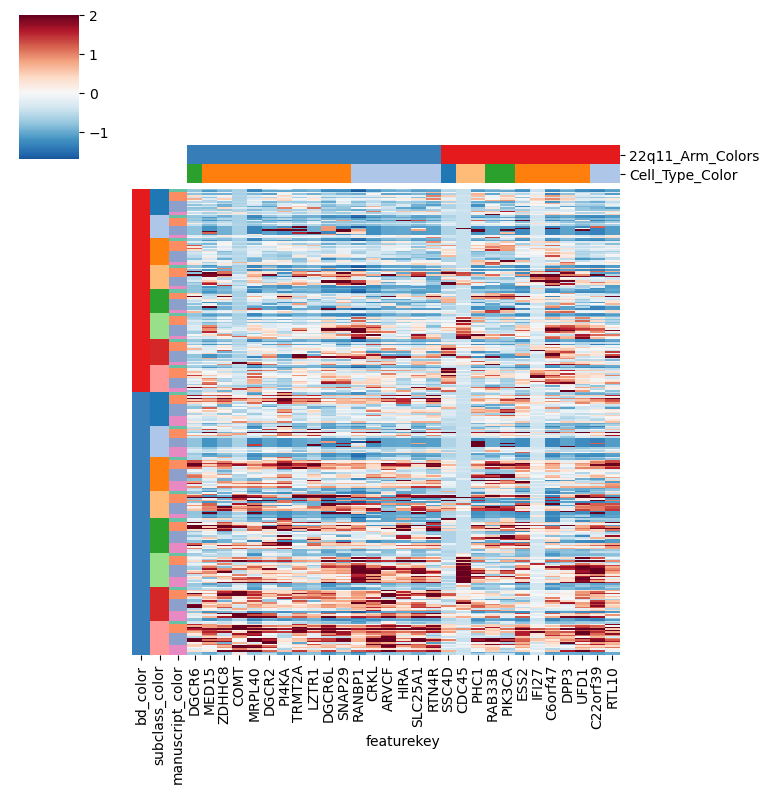

In [38]:
# Turn off clustering since you already sorted
g = sns.clustermap(
    pseudobulk_scaled,
    row_cluster=False,
    col_cluster=False,
    row_colors=manuscript_subclass_df[['bd_color', 'subclass_color', 'manuscript_color']],
    col_colors=celltype_gene_df[['22q11_Arm_Colors', 'Cell_Type_Color']],
    cmap='RdBu_r',
    center=0,
    linewidths=0,
    figsize=(12, 8))

# g.ax_heatmap.set_aspect('auto')
g.ax_heatmap.set_yticklabels([])
g.ax_heatmap.set_ylabel('')
g.ax_heatmap.tick_params(left=False)
g.ax_heatmap.set_yticks([])

In [39]:
## Idiopathic Heatmap ##

# make anndata of 22q11
adata_idiopathic = adata[adata.obs['Broad_Genotype'].str.contains('Idiopathic|Control')]

adata_idiopathic.obs['Donor_Sample_Subclass'] = adata_idiopathic.obs['Donor_Sample'].astype('str') + '_' + adata_idiopathic.obs['subclass_annotations_markers'].astype('str')

# sort genes for 22q11 by celltype
dge_Idiopathic_cutoff_sorted = dge_Idiopathic[(dge_Idiopathic['adj.P.Val'] < 0.05)].sort_values(by=['assay', 'logFC'], ascending=False) 
# dge_Idiopathic_cutoff_sorted = dge_Idiopathic_cutoff_sorted[np.abs(dge_Idiopathic_cutoff_sorted['logFC']) > 1]
SORTED_IDIO_GENES = dge_Idiopathic_cutoff_sorted['ID'].tolist()

adata_idiopathic_df = pd.DataFrame(data=adata_idiopathic[:,SORTED_IDIO_GENES].layers['raw_counts'].toarray(),
                     index=adata_idiopathic.obs_names,
                     columns=adata_idiopathic[:,SORTED_IDIO_GENES].var_names)

# Add Donor_Sample_Subclass Column #
adata_idiopathic_df['Donor_Sample_Subclass'] = adata_idiopathic[:,SORTED_IDIO_GENES].obs['Donor_Sample_Subclass']

# Pseudobulk #
pseudobulk_df = adata_idiopathic_df.groupby('Donor_Sample_Subclass').mean()
pseudobulk_df = np.log1p(pseudobulk_df)

# Create Broad_Genotype with Donor-Broad Genotype dictionary and sort by it #
donor_genotype_dict = dict(zip(adata_idiopathic.obs['Donor_Sample_Subclass'], adata_idiopathic.obs['Broad_Genotype']))
donor_manuscript_dict = dict(zip(adata_idiopathic.obs['Donor_Sample_Subclass'], adata_idiopathic.obs['Manuscript']))
donor_subclass_dict = dict(zip(adata_idiopathic.obs['Donor_Sample_Subclass'], adata_idiopathic.obs['subclass_annotations_markers']))

pseudobulk_df['Broad_Genotype'] = pd.Series(pseudobulk_df.index).apply(lambda x: donor_genotype_dict[x]).values
pseudobulk_df['Manuscript'] = pd.Series(pseudobulk_df.index).apply(lambda x: donor_manuscript_dict[x]).values
pseudobulk_df['Subclass'] = pd.Series(pseudobulk_df.index).apply(lambda x: donor_subclass_dict[x]).values

pseudobulk_df = pseudobulk_df.sort_values(by=['Broad_Genotype', 'Subclass', 'Manuscript'])

/tmp/ipykernel_54616/2167499026.py:6: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_idiopathic.obs['Donor_Sample_Subclass'] = adata_idiopathic.obs['Donor_Sample'].astype('str') + '_' + adata_idiopathic.obs['subclass_annotations_markers'].astype('str')


In [40]:
# Build Row Color DF ##

manuscript_subclass_df = pd.DataFrame({'Manuscript': pd.Series(pseudobulk_df.index).map(donor_manuscript_dict).values,
                                       'Broad_Genotype': pd.Series(pseudobulk_df.index).map(donor_genotype_dict).values,
                                       'Subclass': pd.Series(pseudobulk_df.index).map(donor_subclass_dict).values},
                                        index=pseudobulk_df.index)

## Broad_Genotype Colors ##
broad_genotypes = manuscript_subclass_df['Broad_Genotype'].unique()
bg_palette = sns.color_palette("Set1", len(broad_genotypes))
bg_color_map = dict(zip(broad_genotypes, bg_palette))

# Manuscript Colors #
manuscripts = manuscript_subclass_df['Manuscript'].unique()
manuscript_palette = sns.color_palette("Set2", len(manuscripts))
manuscript_color_map = dict(zip(manuscripts, manuscript_palette))

# Celltype Colors #
subclasses = manuscript_subclass_df['Subclass'].unique()
subclass_palette = sns.color_palette("tab20", len(subclasses))
subclass_color_map = dict(zip(subclasses, subclass_palette))

# Add New Colors #
manuscript_subclass_df['manuscript_color'] = manuscript_subclass_df['Manuscript'].map(manuscript_color_map) #.apply(to_hex)
manuscript_subclass_df['subclass_color'] = manuscript_subclass_df['Subclass'].map(subclass_color_map) #.apply(to_hex)
manuscript_subclass_df['bg_color'] = manuscript_subclass_df['Broad_Genotype'].map(bg_color_map)

# # Reset Index to Broad Genotype #
del pseudobulk_df['Broad_Genotype']
del pseudobulk_df['Manuscript']
del pseudobulk_df['Subclass']

## Build Col Color DF ##

gene_subclass_dict = dict(zip(dge_Idiopathic_cutoff_sorted['ID'], dge_Idiopathic_cutoff_sorted['assay_max']))

dge_Idiopathic_cutoff_sorted['Broad_Genotype'] = dge_Idiopathic_cutoff_sorted['logFC'].apply(lambda x: 'Idiopathic' if x > 0 else 'Control')
gene_idio_disease_dict = dict(zip(dge_Idiopathic_cutoff_sorted['ID'], dge_Idiopathic_cutoff_sorted['Broad_Genotype']))

celltype_gene_df = pd.DataFrame({'Cell Type': pd.Series(pseudobulk_df.columns).map(gene_subclass_dict).values,
                                'Disease Status':pd.Series(pseudobulk_df.columns).map(gene_idio_disease_dict).values},
                                index=pseudobulk_df.columns)

# ## gene-subtypes to colors ##
celltypes = celltype_gene_df['Cell Type'].unique()
celltype_palette = sns.color_palette("tab20", len(celltypes))
celltype_color_map = dict(zip(celltypes, celltype_palette))
celltype_gene_df['Cell_Type_Color'] = celltype_gene_df['Cell Type'].map(celltype_color_map)

# ## gene-disease to colors ##
disease_statuses = celltype_gene_df['Disease Status'].unique()
disease_palette = sns.color_palette("tab20", len(disease_statuses))
disease_color_map = dict(zip(disease_statuses, disease_palette))
celltype_gene_df['Disease_Status_Color'] = celltype_gene_df['Disease Status'].map(disease_color_map)

# # organize genes into subclass
# celltype_gene_df = celltype_gene_df.sort_values(by=['Disease Status', 'Cell Type'], ascending=False)
celltype_gene_df = celltype_gene_df[~celltype_gene_df.index.duplicated(keep='first')]

# # take non duplicate columns
pseudobulk_df = pseudobulk_df[pseudobulk_df.columns.unique()]
pseudobulk_df = pseudobulk_df.loc[:, ~pseudobulk_df.columns.duplicated()]

common_genes = pseudobulk_df.columns.intersection(celltype_gene_df.index)
pseudobulk_df = pseudobulk_df[common_genes]
celltype_gene_df = celltype_gene_df.loc[common_genes]
celltype_gene_df = celltype_gene_df.sort_values(by=['Disease Status', 'Cell Type'], ascending=False)
pseudobulk_df = pseudobulk_df[celltype_gene_df.index]

In [41]:
## Scaling ##

# --- Use original pseudobulk ---
pseudobulk_scaled = pseudobulk_df.copy()

# Z-score per gene (keeps structure but reveals contrast)
pseudobulk_scaled = (
    pseudobulk_scaled - pseudobulk_scaled.mean(axis=0)
) / pseudobulk_scaled.std(axis=0)

# Clip for visualization
pseudobulk_scaled = pseudobulk_scaled.clip(-2, 2)

[]

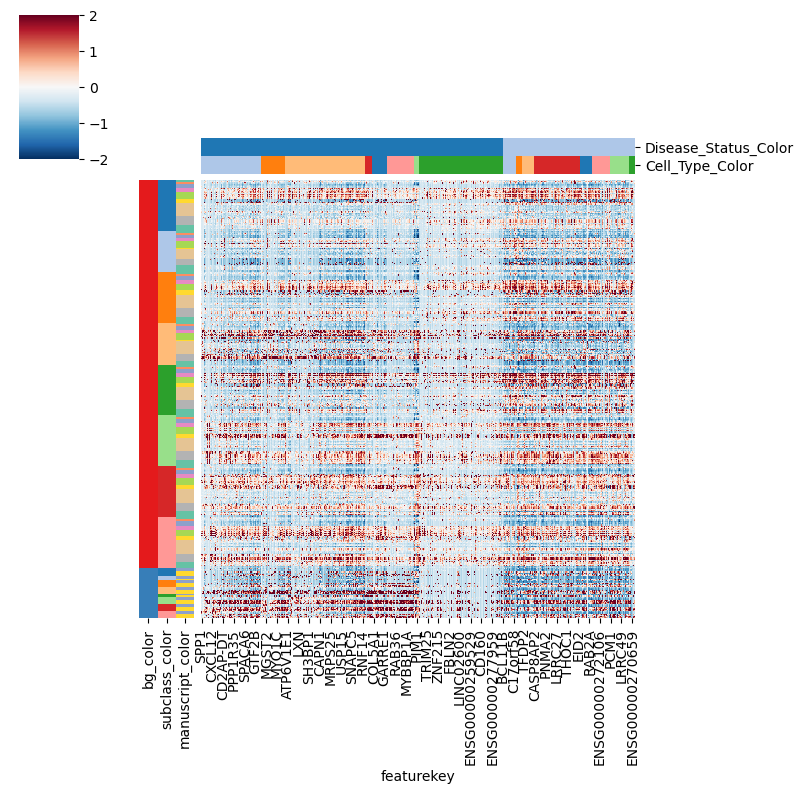

In [42]:
# Turn off clustering since you already sorted
g = sns.clustermap(
    pseudobulk_scaled,
    row_cluster=False,
    col_cluster=False,
    row_colors=manuscript_subclass_df[['bg_color', 'subclass_color', 'manuscript_color']],
    col_colors=celltype_gene_df[['Disease_Status_Color', 'Cell_Type_Color']],
    cmap='RdBu_r',
    center=0,
    linewidths=0,
    figsize=(12, 8))

# g.ax_heatmap.set_aspect('auto')
g.ax_heatmap.set_yticklabels([])
g.ax_heatmap.set_ylabel('')
g.ax_heatmap.tick_params(left=False)
g.ax_heatmap.set_yticks([])

/tmp/ipykernel_54616/3690147177.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


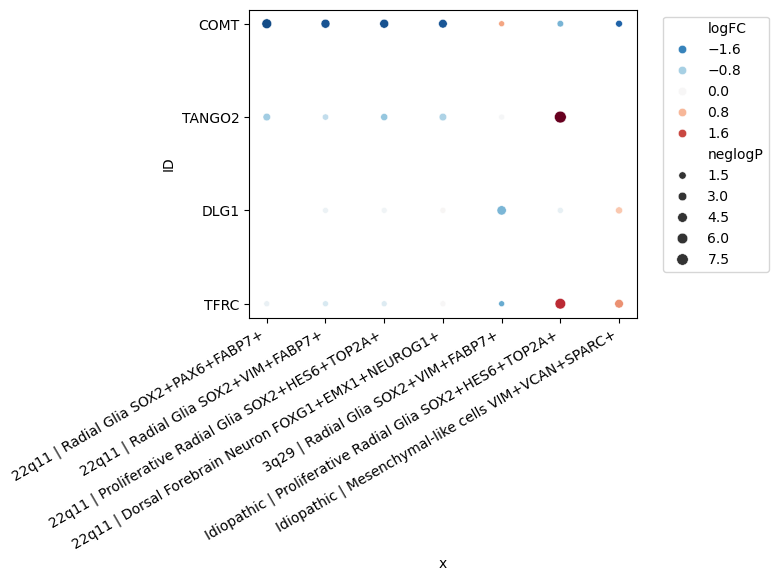

In [23]:
## Checking DGE Against Known Deleted Genes ##

GENES_22q11_3q29_15q13 = CLASSIC_22q11 + ALL_3q29 + ALL_15q13

dfs = [dge_22q11, dge_NRXN1, dge_3q29, dge_15q13, dge_Idiopathic]

all_dges = pd.concat([df.assign(key=k) for df, k in zip(dfs, ["22q11", "NRXN1", "3q29", "15q13", "Idiopathic"])],
                     axis=0, ignore_index=True)

all_dges['neglogP'] = -np.log(all_dges['adj.P.Val'])

# create grouped x-axis label
all_dges["x"] = all_dges["key"].astype(str) + " | " + all_dges["assay"]

dotplot_genes = all_dges[all_dges["ID"].isin(GENES_22q11_3q29_15q13) & (all_dges["adj.P.Val"] < 0.05)]['ID'].unique().tolist()
dotplot_assays = all_dges[all_dges["ID"].isin(GENES_22q11_3q29_15q13) & (all_dges["adj.P.Val"] < 0.05)]['x'].unique().tolist()

all_dges = all_dges[all_dges["ID"].isin(dotplot_genes) & all_dges['x'].isin(dotplot_assays)]

# get ordering right 
x_order = all_dges["x"].drop_duplicates().tolist()
all_dges["x"] = pd.Categorical(all_dges["x"], categories=x_order, ordered=True)

y_order = ['COMT', 'TANGO2', 'DLG1',  'TFRC']
all_dges["ID"] = pd.Categorical(all_dges["ID"], categories=y_order, ordered=True)

## Plot

# Set a diverging colormap, e.g., red-white-blue
cmap = plt.get_cmap("RdBu_r")  # _r reverses it so red = positive, blue = negative

# Scatterplot
ax = sns.scatterplot(
    data=all_dges,
    x="x",
    y="ID",
    hue="logFC",
    size="neglogP",
    palette=cmap,
    hue_norm=(-all_dges["logFC"].abs().max(), all_dges["logFC"].abs().max())  # centers around 0
)

# Figure adjustments
ax.figure.set_size_inches(5, 4)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

In [24]:
# intersection_genes = list(set_idiopathic.intersection(set_3q29)) + list(set_idiopathic.intersection(set_22q11))

In [25]:
intersection_values_df = pd.DataFrame(data=adata[:,intersection_genes].X.toarray(),
                         index=adata[:,intersection_genes].obs_names,
                         columns=intersection_genes)

intersection_values_df['Broad_Genotype'] = adata.obs['Broad_Genotype']
intersection_values_df['subclass_annotations_markers'] = adata.obs['subclass_annotations_markers']

intersection_values_df_melted = pd.melt(intersection_values_df,
                                        id_vars=['Broad_Genotype', 'subclass_annotations_markers'], 
                                        var_name='Gene', value_name='Expression')

intersection_values_df_melted = intersection_values_df_melted[intersection_values_df_melted['Broad_Genotype'].str.contains('22q11|Control|3q29|Idiopathic')]

intersection_values_df_melted['Broad_Genotype'] = intersection_values_df_melted['Broad_Genotype'].astype('str')

/tmp/ipykernel_54616/3729731056.py:18: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


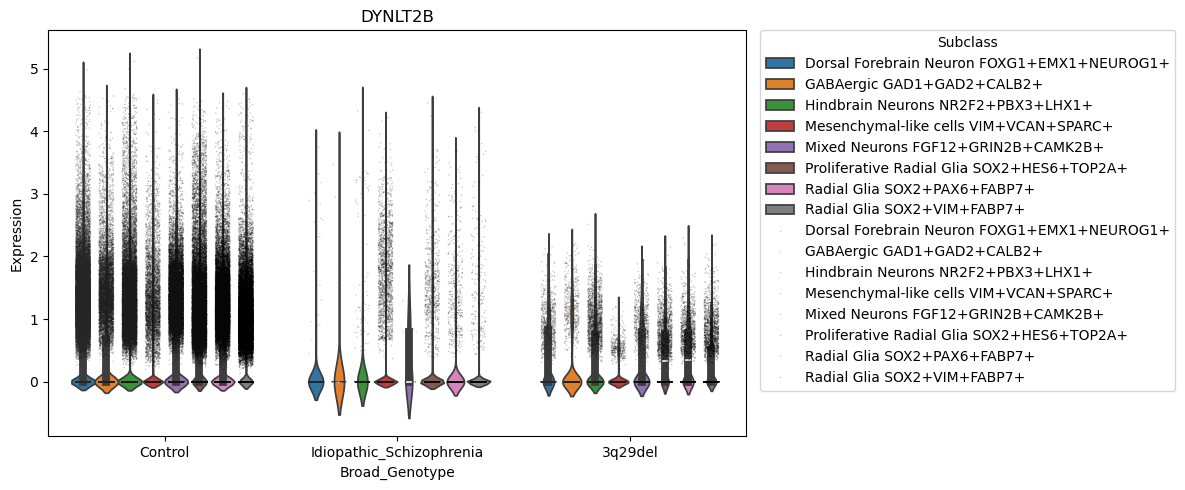

/tmp/ipykernel_54616/3729731056.py:18: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


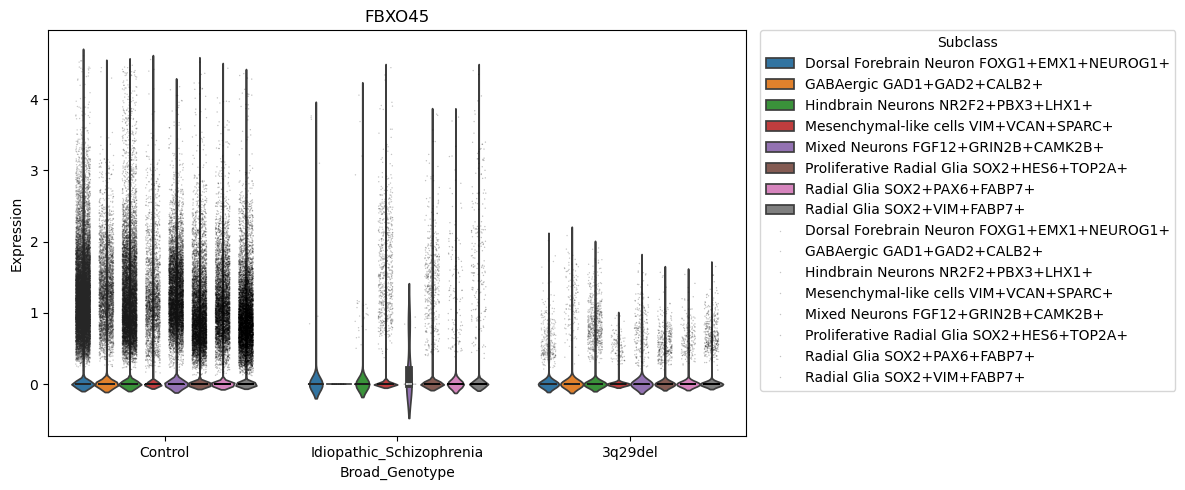

/tmp/ipykernel_54616/3729731056.py:49: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


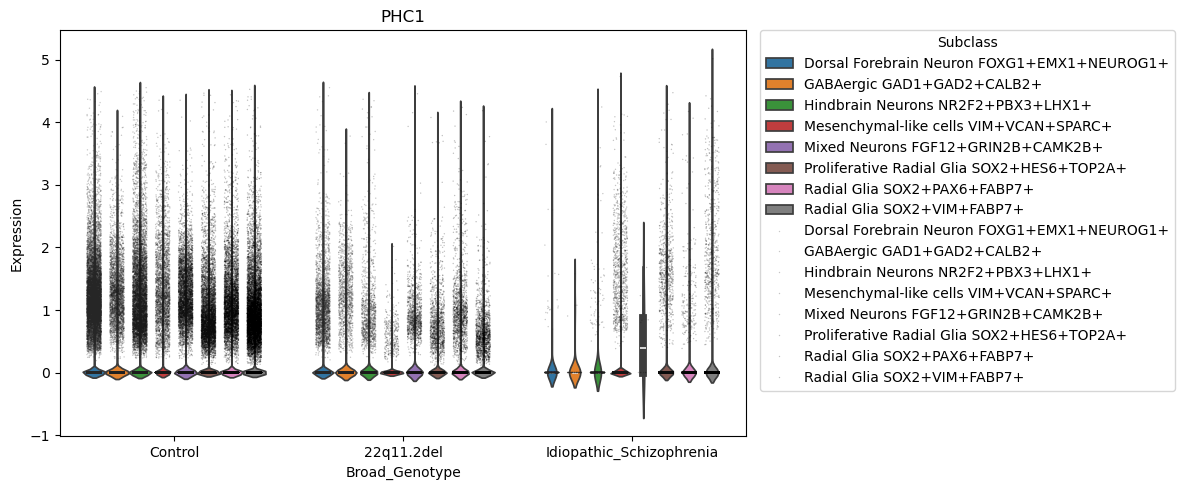

/tmp/ipykernel_54616/3729731056.py:49: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


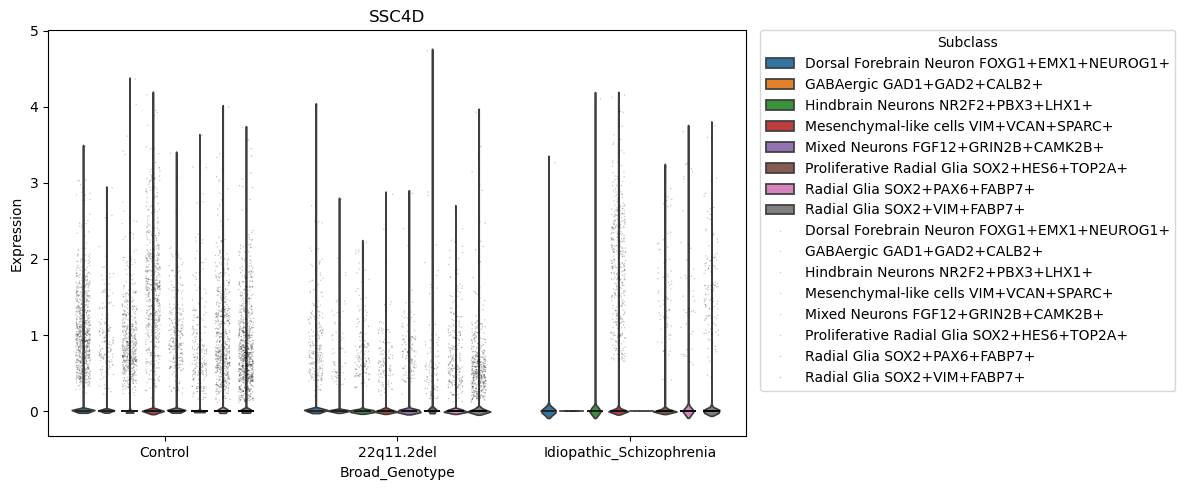

In [26]:
for gene in intersection_values_df_melted['Gene'].unique():

    if gene in list(set_idiopathic.intersection(set_3q29)):

        control_3q29_bool = intersection_values_df_melted['Broad_Genotype'].str.contains('3q29|Control|Idiopathic')

        plt.figure(figsize=(12, 5))  # wider plot
        

        ax = sns.violinplot(data=intersection_values_df_melted[(intersection_values_df_melted['Gene'] == gene) & control_3q29_bool],
                            x='Broad_Genotype',
                            hue='subclass_annotations_markers',
                            y='Expression')
        
        ax.set_title(gene)

            # --- stripplot on top ---
        sns.stripplot(
            data=intersection_values_df_melted[(intersection_values_df_melted['Gene'] == gene) & control_3q29_bool],
            x='Broad_Genotype',
            hue='subclass_annotations_markers',
            y='Expression',
            dodge=True,
            jitter=0.25,
            size=1,
            alpha=0.25,
            color='black'
        )

        # move legend outside
        plt.legend(title='Subclass', bbox_to_anchor=(1.02, 1), loc='upper left',  borderaxespad=0)
    
        plt.tight_layout()  # prevents clipping
        plt.show()

    else:

        control_22q11_bool = intersection_values_df_melted['Broad_Genotype'].str.contains('22q11|Control|Idiopathic')

        plt.figure(figsize=(12, 5))  # wider plot
    
        ax = sns.violinplot(data=intersection_values_df_melted[(intersection_values_df_melted['Gene'] == gene) & control_22q11_bool],
                            x='Broad_Genotype',
                            hue='subclass_annotations_markers',
                            y='Expression')

        ax.set_title(gene)

        sns.stripplot(
            data=intersection_values_df_melted[(intersection_values_df_melted['Gene'] == gene) & control_22q11_bool],
            x='Broad_Genotype',
            hue='subclass_annotations_markers',
            y='Expression',
            dodge=True,
            jitter=0.25,
            size=1,
            alpha=0.25,
            color='black'
        )

        # move legend outside
        plt.legend(title='Subclass', bbox_to_anchor=(1.02, 1), loc='upper left',  borderaxespad=0)
    
        plt.tight_layout()  # prevents clipping
        plt.show()   

In [ ]:
# logFC between manjuscripts and show covariates help you get the concordance up across manuscrispt for a genotype’s DGEs

In [44]:
significant_22q11s = dge_22q11[dge_22q11['adj.P.Val'] < 0.05]['ID']

In [ ]:
glob.glob('

In [95]:
## Read In Individual DGE Signatures ##

dge_khan = pd.read_csv(Path(CSV_PATH) / 'dreamlet_khan_dge_scz_results.csv')
dge_shin = pd.read_csv(Path(CSV_PATH) / 'dreamlet_shin_dge_scz_results.csv')
dge_walsh_22q11 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_walsh_22q11_dge_scz_results.csv')
dge_khan_rao = pd.read_csv(Path(CSV_PATH) / 'dreamlet_rao_dge_scz_results.csv')

dge_khan['assay_ID'] = dge_khan['assay'] = dge_khan['assay'] + '_' + dge_khan['ID'] 
dge_shin['assay_ID'] = dge_shin['assay'] + '_' + dge_shin['ID'] 
dge_walsh_22q11['assay_ID'] = dge_walsh_22q11['assay'] + '_' + dge_walsh_22q11['ID'] 
dge_khan_rao['assay_ID'] = dge_khan_rao['assay'] + '_' + dge_khan_rao['ID'] 

In [96]:
## Filter on Significant 22q11 Across Manuscripts ##

dge_khan_filtered = dge_khan[dge_khan['ID'].isin(significant_22q11s)]
dge_shin_filtered = dge_shin[dge_shin['ID'].isin(significant_22q11s)]
dge_walsh_22q11_filtered = dge_walsh_22q11[dge_walsh_22q11['ID'].isin(significant_22q11s)]
dge_rao_filtered = dge_khan_rao[dge_khan_rao['ID'].isin(significant_22q11s)]

In [97]:
## Khan vs Shin ##

khan_shin_shared_gene_cells = set(dge_khan_filtered['assay_ID']).intersection(set(dge_shin_filtered['assay_ID']))

dge_khan_filtered_shared_with_shin = dge_khan_filtered[dge_khan_filtered['assay_ID'].isin(khan_shin_shared_gene_cells)]
dge_khan_filtered_shared_with_shin = dge_khan_filtered_shared_with_shin.sort_values(by='assay_ID')

dge_shin_filtered_shared_with_khan = dge_shin_filtered[dge_shin_filtered['assay_ID'].isin(khan_shin_shared_gene_cells)]
dge_shin_filtered_shared_with_khan = dge_shin_filtered_shared_with_khan.sort_values(by='assay_ID')

dge_shin_khan_merged = pd.merge(dge_khan_filtered_shared_with_shin, dge_shin_filtered_shared_with_khan, 
                                  how='inner', left_on='assay_ID', 
                                  right_on='assay_ID', suffixes=['_khan', '_shin'])

Text(0.05, 0.95, '$R = 0.22$')

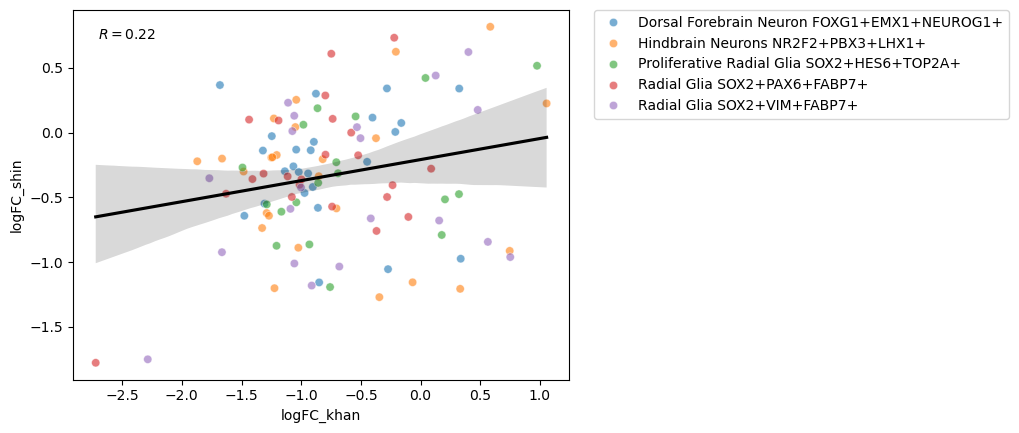

In [109]:
ax = sns.scatterplot(data=dge_shin_khan_merged, x='logFC_khan', y='logFC_shin', hue='assay_shin', alpha=0.6)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

sns.regplot(data=dge_shin_khan_merged, x='logFC_khan', y='logFC_shin',  scatter=False, ax=ax, color='black')

x = dge_shin_khan_merged['logFC_khan']
y = dge_shin_khan_merged['logFC_shin']

r = linregress(x, y).rvalue

ax.text(0.05, 0.95,  f'$R = {r:.2f}$',  transform=ax.transAxes,  ha='left',  va='top')

In [91]:
dge_shin_khan_merged

,assay_khan,ID_khan,logFC_khan,AveExpr_khan,t_khan,P.Value_khan,adj.P.Val_khan,B_khan,z.std_khan,assay_ID,assay_shin,ID_shin,logFC_shin,AveExpr_shin,t_shin,P.Value_shin,adj.P.Val_shin,B_shin,z.std_shin
0,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,ARVCF,-0.549048,3.404155,-1.846554,0.080650,0.562262,-4.533915,-1.846554,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+_ARVCF,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,ARVCF,-0.549048,3.404155,-1.846554,0.080650,0.562262,-4.533915,-1.846554
1,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,C22orf39,-0.581263,5.229963,-2.543702,0.019947,0.562262,-4.426638,-2.543702,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+_C2...,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,C22orf39,-0.581263,5.229963,-2.543702,0.019947,0.562262,-4.426638,-2.543702
2,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,C6orf47,0.073798,3.999632,0.177944,0.860674,0.949535,-4.628939,0.177944,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+_C6...,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,C6orf47,0.073798,3.999632,0.177944,0.860674,0.949535,-4.628939,0.177944
3,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,CRKL,-0.027848,4.614771,-0.083933,0.933999,0.976677,-4.633811,-0.083933,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+_CRKL,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,CRKL,-0.027848,4.614771,-0.083933,0.933999,0.976677,-4.633811,-0.083933
4,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,DGCR2,-0.420348,3.169067,-1.106072,0.282678,0.654445,-4.589838,-1.106072,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+_DGCR2,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,DGCR2,-0.420348,3.169067,-1.106072,0.282678,0.654445,-4.589838,-1.106072
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,Radial Glia SOX2+VIM+FABP7+,RANBP1,-0.043566,7.563520,-0.172443,0.865089,0.950975,-5.693160,-0.172443,Radial Glia SOX2+VIM+FABP7+_RANBP1,Radial Glia SOX2+VIM+FABP7+,RANBP1,-0.043566,7.563520,-0.172443,0.865089,0.950975,-5.693160,-0.172443
107,Radial Glia SOX2+VIM+FABP7+,RTN4R,-0.679345,2.670859,-1.568200,0.134924,0.570062,-4.408663,-1.568200,Radial Glia SOX2+VIM+FABP7+_RTN4R,Radial Glia SOX2+VIM+FABP7+,RTN4R,-0.679345,2.670859,-1.568200,0.134924,0.570062,-4.408663,-1.568200
108,Radial Glia SOX2+VIM+FABP7+,SNAP29,0.011062,5.113590,0.040325,0.968295,0.989403,-5.578422,0.040325,Radial Glia SOX2+VIM+FABP7+_SNAP29,Radial Glia SOX2+VIM+FABP7+,SNAP29,0.011062,5.113590,0.040325,0.968295,0.989403,-5.578422,0.040325
109,Radial Glia SOX2+VIM+FABP7+,TRMT2A,0.230148,3.717594,0.743659,0.467053,0.763438,-5.206583,0.743659,Radial Glia SOX2+VIM+FABP7+_TRMT2A,Radial Glia SOX2+VIM+FABP7+,TRMT2A,0.230148,3.717594,0.743659,0.467053,0.763438,-5.206583,0.743659


In [ ]:
## celltypes different colors
## correlation is between manuscripts
## points different genes ##

In [27]:
dge_22q11[dge_22q11['adj.P.Val'] < 0.05].groupby('assay').count()

,ID,logFC,AveExpr,t,P.Value,adj.P.Val,B,z.std,chromosome_name,assay_max
assay,,,,,,,,,,
Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,12,12,12,12,12,12,12,12,12,12
Hindbrain Neurons NR2F2+PBX3+LHX1+,15,15,15,15,15,15,15,15,15,15
Mesenchymal-like cells VIM+VCAN+SPARC+,6,6,6,6,6,6,6,6,6,6
Mixed Neurons FGF12+GRIN2B+CAMK2B+,10,10,10,10,10,10,10,10,10,10
Proliferative Radial Glia SOX2+HES6+TOP2A+,10,10,10,10,10,10,10,10,10,10
Radial Glia SOX2+PAX6+FABP7+,9,9,9,9,9,9,9,9,9,9
Radial Glia SOX2+VIM+FABP7+,11,11,11,11,11,11,11,11,11,11


In [28]:
dge_NRXN1[dge_NRXN1['adj.P.Val'] < 0.05].groupby('assay').count()

,ID,logFC,AveExpr,t,P.Value,adj.P.Val,B,z.std,chromosome_name
assay,,,,,,,,,


In [29]:
dge_3q29[dge_3q29['adj.P.Val'] < 0.05].groupby('assay').count()

,ID,logFC,AveExpr,t,P.Value,adj.P.Val,B,z.std,chromosome_name
assay,,,,,,,,,
Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,7,7,7,7,7,7,7,7,7
GABAergic GAD1+GAD2+CALB2+,5,5,5,5,5,5,5,5,5
Hindbrain Neurons NR2F2+PBX3+LHX1+,7,7,7,7,7,7,7,7,7
Mixed Neurons FGF12+GRIN2B+CAMK2B+,7,7,7,7,7,7,7,7,7
Proliferative Radial Glia SOX2+HES6+TOP2A+,8,8,8,8,8,8,8,8,8
Radial Glia SOX2+PAX6+FABP7+,6,6,6,6,6,6,6,6,6
Radial Glia SOX2+VIM+FABP7+,11,11,11,11,11,11,11,11,11


In [30]:
dge_15q13[dge_15q13['adj.P.Val'] < 0.05]

,assay,ID,logFC,AveExpr,t,P.Value,adj.P.Val,B,z.std,chromosome_name
0,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,POTEI,6.167636,0.522849,8.477168,1.587479e-11,0.000002,0.395482,6.739669,2
1,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,TCEAL5,3.669027,4.726192,8.074775,5.796995e-11,0.000003,0.029205,6.548881,X
2,Hindbrain Neurons NR2F2+PBX3+LHX1+,BEX5,3.121476,6.136359,5.864902,8.955599e-08,0.002938,-0.828788,5.346733,X
3,Mixed Neurons FGF12+GRIN2B+CAMK2B+,TCEAL5,3.550654,5.100639,5.936344,4.609436e-07,0.011341,-3.504691,5.041895,X
4,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,BEX5,3.769373,5.570494,5.142557,2.019086e-06,0.038253,-1.904604,4.751505,X
5,GABAergic GAD1+GAD2+CALB2+,BEX5,3.582438,5.724576,5.373402,2.332071e-06,0.038253,4.187765,4.722287,X


In [31]:
dge_15q13[dge_15q13['adj.P.Val'] < 0.05].groupby('assay').count()

,ID,logFC,AveExpr,t,P.Value,adj.P.Val,B,z.std,chromosome_name
assay,,,,,,,,,
Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,3,3,3,3,3,3,3,3,3
GABAergic GAD1+GAD2+CALB2+,1,1,1,1,1,1,1,1,1
Hindbrain Neurons NR2F2+PBX3+LHX1+,1,1,1,1,1,1,1,1,1
Mixed Neurons FGF12+GRIN2B+CAMK2B+,1,1,1,1,1,1,1,1,1


In [32]:
dge_Idiopathic[dge_Idiopathic['adj.P.Val'] < 0.05].groupby('assay').count()

,ID,logFC,AveExpr,t,P.Value,adj.P.Val,B,z.std,chromosome_name,assay_max
assay,,,,,,,,,,
Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,441,441,441,441,441,441,441,441,441,441
GABAergic GAD1+GAD2+CALB2+,56,56,56,56,56,56,56,56,56,56
Hindbrain Neurons NR2F2+PBX3+LHX1+,121,121,121,121,121,121,121,121,121,121
Mesenchymal-like cells VIM+VCAN+SPARC+,147,147,147,147,147,147,147,147,147,147
Mixed Neurons FGF12+GRIN2B+CAMK2B+,34,34,34,34,34,34,34,34,34,34
Proliferative Radial Glia SOX2+HES6+TOP2A+,519,519,519,519,519,519,519,519,519,519
Radial Glia SOX2+PAX6+FABP7+,159,159,159,159,159,159,159,159,159,159
Radial Glia SOX2+VIM+FABP7+,327,327,327,327,327,327,327,327,327,327


In [33]:
## negative overlap and shared lists ##

## code to test difference of differences ##

# 